In [10]:
import os
import pandas as pd

import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
TESS_BASE_DIR = "audio_speech/TESS/"

In [3]:
tess_directory_list = os.listdir(TESS_BASE_DIR)

file_emotion = []
file_path = []

for dir in tess_directory_list:
    for file in os.listdir(TESS_BASE_DIR + dir): # returns a list of all the file/audio names in each directory
        # Extract emotion
        emotion = file.split('.')[0]    # i.e. ['OAF_back_angry', 'wav'], pos 0 gets what we want
        emotion = emotion.split('_')[2] # i.e. ['OAF', 'back', 'angry'], pos 2 gets what we want

        # To match the ravdess encodings
        if emotion == 'neutral':
            file_emotion.append(1)
        elif emotion == 'happy':
            file_emotion.append(2)
        elif emotion == 'sad':
            file_emotion.append(3)
        elif emotion == 'angry':
            file_emotion.append(4)
        elif emotion == 'fear':
            file_emotion.append(5)
        elif emotion == 'disgust':
            file_emotion.append(6)
        elif emotion == 'ps':
            file_emotion.append(7)
        else:
            file_emotion.append(0)

        # Get path of each audio file
        file_path.append(TESS_BASE_DIR + dir + '/' + file)

In [4]:
df = pd.DataFrame(list(zip(file_path, file_emotion)), columns=['file_path', 'Emotion'])
df.head()

,file_path,Emotion
0,audio_speech/TESS/OAF_angry/OAF_back_angry.wav,4
1,audio_speech/TESS/OAF_angry/OAF_bar_angry.wav,4
2,audio_speech/TESS/OAF_angry/OAF_base_angry.wav,4
3,audio_speech/TESS/OAF_angry/OAF_bath_angry.wav,4
4,audio_speech/TESS/OAF_angry/OAF_bean_angry.wav,4


In [5]:
# Add human readable labels to the emotions
emotion_map = {
    1: "neutral",
    2: "happy",
    3: "sad",
    4: "angry",
    5: "fearful",
    6: "disgust",
    7: "surprised"
}

df["Emotion_label"] = df["Emotion"].map(emotion_map)

In [6]:
df.Emotion_label.value_counts().sort_index()

Emotion_label
angry        400
disgust      400
fearful      400
happy        400
neutral      400
sad          400
surprised    400
Name: count, dtype: int64

In [7]:
df.head()

,file_path,Emotion,Emotion_label
0,audio_speech/TESS/OAF_angry/OAF_back_angry.wav,4,angry
1,audio_speech/TESS/OAF_angry/OAF_bar_angry.wav,4,angry
2,audio_speech/TESS/OAF_angry/OAF_base_angry.wav,4,angry
3,audio_speech/TESS/OAF_angry/OAF_bath_angry.wav,4,angry
4,audio_speech/TESS/OAF_angry/OAF_bean_angry.wav,4,angry


## Export dataset

In [8]:
df.to_csv("tess_labels.csv", index=False)

### Exploring dataset

In [11]:
# Get duration of each audio clip
durations = []  # to store each file's duration

for path in df['file_path']:
    try:
        y, sr = librosa.load(path, sr=None)  # sr=None preserves original sampling rate
        duration = librosa.get_duration(y=y, sr=sr)
        durations.append(duration)
    except Exception as e:
        print(f"Error loading {path}: {e}")
        durations.append(None)

# Add durations to dataframe
df['duration'] = durations


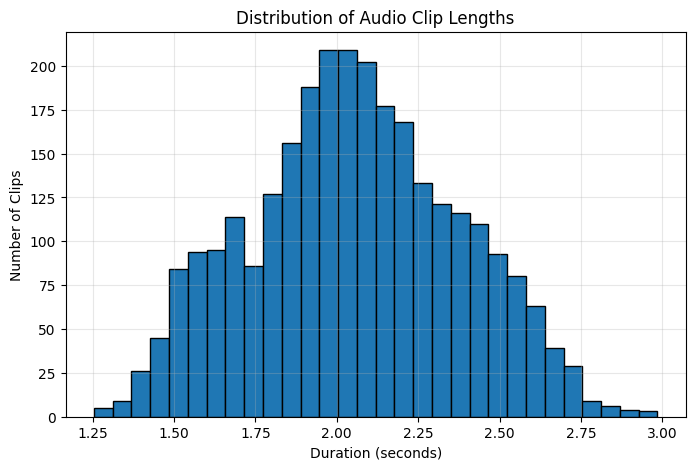

In [12]:
# Plot distribution of audio clip length
plt.figure(figsize=(8, 5))
plt.hist(df['duration'], bins=30, edgecolor='black')
plt.title('Distribution of Audio Clip Lengths')
plt.xlabel('Duration (seconds)')
plt.ylabel('Number of Clips')
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
# Find min & max audio duration
shortest = df.loc[df['duration'].idxmin()]
longest = df.loc[df['duration'].idxmax()]

print(f"Shortest clip: {shortest['file_path']} ({shortest['duration']:.2f} sec)")
print(f"Longest clip: {longest['file_path']} ({longest['duration']:.2f} sec)")

Shortest clip: audio_speech/TESS/YAF_fear/YAF_choice_fear.wav (1.25 sec)
Longest clip: audio_speech/TESS/OAF_sad/OAF_gap_sad.wav (2.98 sec)


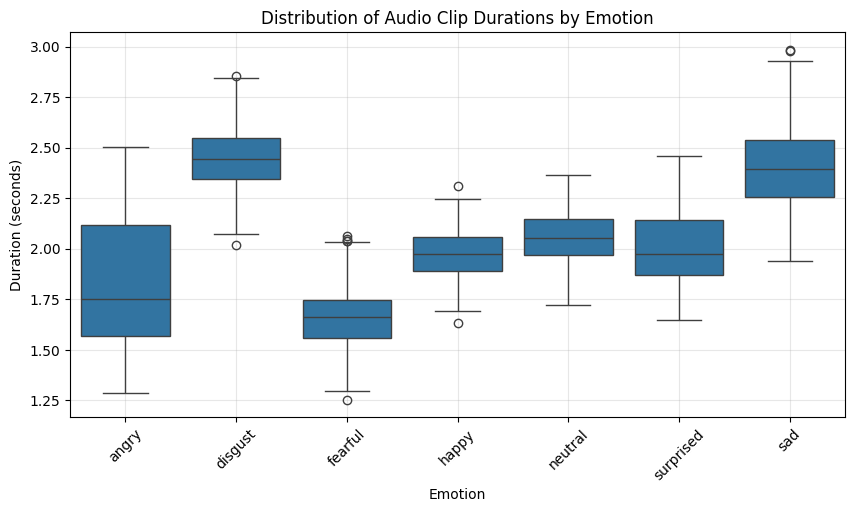

In [14]:
# Distribution of Audio Clip Durations by Emotion
plt.figure(figsize=(10, 5))
sns.boxplot(x='Emotion_label', y='duration', data=df)
plt.title('Distribution of Audio Clip Durations by Emotion')
plt.xlabel('Emotion')
plt.ylabel('Duration (seconds)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()